
Loaded groups:
0.0: 15 spectra
0.25: 15 spectra
0.5: 15 spectra
0.75: 15 spectra
1.0: 15 spectra

Common range:
400.639 4000.123


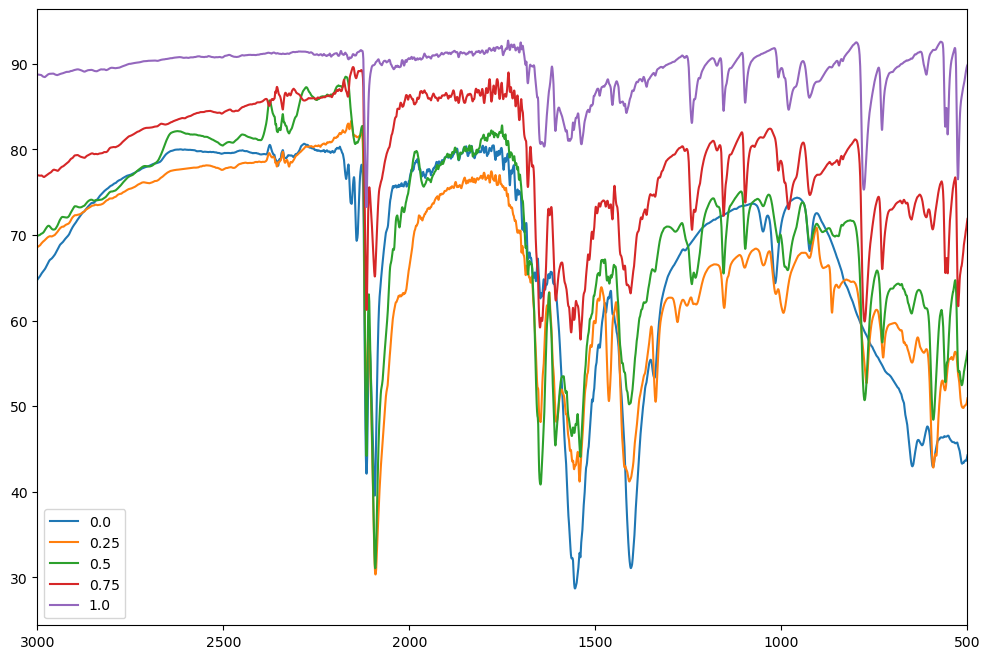

0.0 minimum = 39.55353512371956 maximum = 80.32947960479474
0.25 minimum = 30.32980786521057 maximum = 83.33645219284261
0.5 minimum = 31.053927452989992 maximum = 88.51032485579621
0.75 minimum = 61.25425531445871 maximum = 89.63232793425735
1.0 minimum = 73.28057093697329 maximum = 91.61630919926618
0.0 39.55353512371956
0.25 30.32980786521057
0.5 31.053927452989992
0.75 61.25425531445871
1.0 73.28057093697329


In [3]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================================
# SETTINGS
# ==========================================================

DATA_FOLDER = r"/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2026_015"

STD_MIN = 2000
STD_MAX = 2200

OUTPUT_FOLDER = os.path.join(DATA_FOLDER, "normalized_output")
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

# ==========================================================
# LOAD SPECTRUM
# ==========================================================

def read_spectrum(filepath):

    df = pd.read_csv(filepath)

    wn = pd.to_numeric(df.iloc[:, 0], errors="coerce")
    absorbance = pd.to_numeric(df.iloc[:, 1], errors="coerce")

    mask = ~(wn.isna() | absorbance.isna())

    wn = wn[mask].to_numpy()
    absorbance = absorbance[mask].to_numpy()

    return wn, absorbance

# ==========================================================
# IDENTIFY SAMPLE RATIO
# ==========================================================

def get_ratio(filename):

    name = filename.lower()

    if "_alpha_" in name:
        return 1.00

    if "_agoac_" in name:
        return 0.00

    match = re.search(r'0\.25|0\.5|0\.75', name)

    if match:
        return float(match.group())

    return None

# ==========================================================
# LOAD ALL FILES
# ==========================================================

groups = {}

all_min_wn = []
all_max_wn = []

for file in os.listdir(DATA_FOLDER):

    if not file.endswith(".CSV"):
        continue

    ratio = get_ratio(file)

    if ratio is None:
        continue

    path = os.path.join(DATA_FOLDER, file)

    wn, absorbance = read_spectrum(path)

    all_min_wn.append(np.min(wn))
    all_max_wn.append(np.max(wn))

    groups.setdefault(ratio, []).append((wn, absorbance))

print("\nLoaded groups:")
for ratio in sorted(groups):
    print(f"{ratio}: {len(groups[ratio])} spectra")

# ==========================================================
# COMMON WAVENUMBER GRID
# ==========================================================

common_min = max(all_min_wn)
common_max = min(all_max_wn)

common_wn = np.linspace(
    common_min,
    common_max,
    7000
)

print("\nCommon range:")
print(common_min, common_max)

# ==========================================================
# INTERPOLATE + AVERAGE
# ==========================================================

avg_spectra = {}

for ratio, spectra in groups.items():

    interpolated = []

    for wn, absorbance in spectra:

        order = np.argsort(wn)

        wn = wn[order]
        absorbance = absorbance[order]

        interp = np.interp(
            common_wn,
            wn,
            absorbance
        )

        interpolated.append(interp)

    interpolated = np.array(interpolated)

    avg_spectra[ratio] = np.mean(
        interpolated,
        axis=0
    )

# ==========================================================
# FIND FERRICYANIDE PEAK DEPTH
# ==========================================================

std_mask = (
    (common_wn >= STD_MIN) &
    (common_wn <= STD_MAX)
)

peak_depths = {}

for ratio, spectrum in avg_spectra.items():

    ferri_region = spectrum[std_mask]

    peak_depths[ratio] = np.min(ferri_region)

plt.figure(figsize=(12,8))

for ratio in sorted(avg_spectra):

    plt.plot(
        common_wn,
        avg_spectra[ratio],
        label=f"{ratio}"
    )
plt.xlim(500, 3000)
plt.gca().invert_xaxis()
plt.legend()
plt.show()

for ratio in sorted(avg_spectra):

    ferri_region = avg_spectra[ratio][std_mask]

    print(
        ratio,
        "minimum =", np.min(ferri_region),
        "maximum =", np.max(ferri_region)
    )
for ratio in sorted(avg_spectra):

    ferri_region = avg_spectra[ratio][std_mask]

    print(
        ratio,
        np.min(ferri_region)
    )



Loaded groups:
0.0: 15 spectra
0.25: 15 spectra
0.5: 15 spectra
0.75: 15 spectra
1.0: 15 spectra

Reference (0.25):
Peak: 21.290014826698386
Base: 90.63583859943478

Affine normalization parameters:
Ratio 0.00 | a=1.565248 | b=-37.971237
Ratio 0.50 | a=1.314841 | b=-24.517861
Ratio 0.75 | a=1.581376 | b=-49.903732
Ratio 1.00 | a=2.201741 | b=-100.140482
Ratio 0.25 | a=1.000000 | b=0.000000


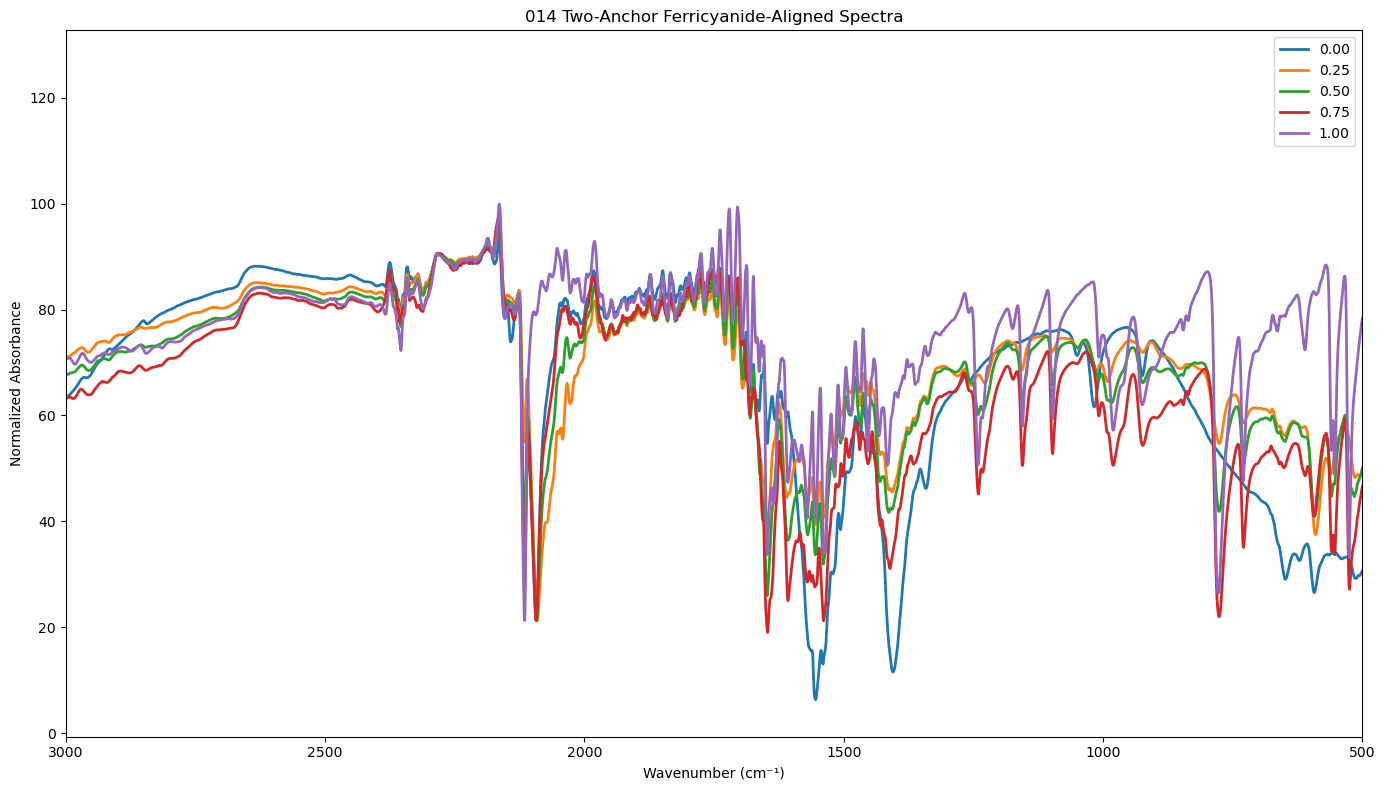


DONE.


In [5]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_FOLDER = r"/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2026_014"
OUTPUT_FOLDER = os.path.join(DATA_FOLDER, "response_factor_affine_output")
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

REFERENCE_RATIO = 0.25

# Ferricyanide regions
PEAK_MIN, PEAK_MAX = 2000, 2200   # peak (dip)
BASE_MIN, BASE_MAX = 2200, 2400   # baseline (stem)

# LOAD SPECTRUM

def read_spectrum(filepath):
    df = pd.read_csv(filepath)

    wn = pd.to_numeric(df.iloc[:, 0], errors="coerce")
    absorbance = pd.to_numeric(df.iloc[:, 1], errors="coerce")

    mask = ~(wn.isna() | absorbance.isna())

    return wn[mask].to_numpy(), absorbance[mask].to_numpy()

# PARSE RATIO

def get_ratio(filename):
    name = filename.lower()

    if "_alpha_" in name:
        return 1.0
    if "_agoac_" in name:
        return 0.0

    match = re.search(r'0\.25|0\.5|0\.75', name)
    return float(match.group()) if match else None

# GROUP FILES

groups = {}
all_min, all_max = [], []

for file in os.listdir(DATA_FOLDER):

    if not file.endswith(".CSV"):
        continue

    ratio = get_ratio(file)
    if ratio is None:
        continue

    path = os.path.join(DATA_FOLDER, file)

    wn, abs_ = read_spectrum(path)

    all_min.append(np.min(wn))
    all_max.append(np.max(wn))

    groups.setdefault(ratio, []).append((wn, abs_))

print("\nLoaded groups:")
for r in sorted(groups):
    print(f"{r}: {len(groups[r])} spectra")

# COMMON GRID

common_wn = np.linspace(max(all_min), min(all_max), 7000)

# INTERPOLATE + AVERAGE

avg_spectra = {}

for ratio, spectra in groups.items():

    interp_list = []

    for wn, abs_ in spectra:

        order = np.argsort(wn)
        wn = wn[order]
        abs_ = abs_[order]

        interp = np.interp(common_wn, wn, abs_)
        interp_list.append(interp)

    avg_spectra[ratio] = np.mean(interp_list, axis=0)

# FERRICYANIDE FEATURE EXTRACTION

def ferri_features(wn, spectrum):

    peak_mask = (wn >= PEAK_MIN) & (wn <= PEAK_MAX)
    base_mask = (wn >= BASE_MIN) & (wn <= BASE_MAX)

    peak_region = spectrum[peak_mask]
    base_region = spectrum[base_mask]

    peak_val = np.min(peak_region)   # dip
    base_val = np.max(base_region)   # stem

    return peak_val, base_val

# REFERENCE FEATURES (0.25)

ref_spectrum = avg_spectra[REFERENCE_RATIO]
ref_peak, ref_base = ferri_features(common_wn, ref_spectrum)

print("\nReference (0.25):")
print("Peak:", ref_peak)
print("Base:", ref_base)

# TWO-POINT AFFINE NORMALIZATION

normalized = {}

print("\nAffine normalization parameters:")

for ratio, spectrum in avg_spectra.items():

    peak, base = ferri_features(common_wn, spectrum)

    # Solve:
    # a*peak + b = ref_peak
    # a*base + b = ref_base

    a = (ref_base - ref_peak) / (base - peak)
    b = ref_peak - a * peak

    normalized[ratio] = a * spectrum + b

    print(f"Ratio {ratio:.2f} | a={a:.6f} | b={b:.6f}")

# OVERLAY PLOT (CHECK ALIGNMENT)

plt.figure(figsize=(14, 8))

for ratio in sorted(normalized):

    plt.plot(
        common_wn,
        normalized[ratio],
        linewidth=2,
        label=f"{ratio:.2f}"
    )

plt.gca().invert_xaxis()
plt.xlim(500, 3000)

plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Normalized Absorbance")
plt.title("014 Two-Anchor Ferricyanide-Aligned Spectra")

plt.legend()
plt.tight_layout()

plt.savefig(
    os.path.join(OUTPUT_FOLDER, "affine_normalized_overlay.png"),
    dpi=300
)
plt.gca().invert_xaxis()
plt.show()

print("\nDONE.")


Loaded groups:
0.0: 15 spectra
0.25: 15 spectra
0.5: 15 spectra
0.75: 15 spectra
1.0: 15 spectra

Reference (0.25):
Peak: 30.32980786521057
Base: 81.38784647981838

Affine normalization parameters:
Ratio 0.25 | a=1.000000 | b=0.000000
Ratio 0.75 | a=1.959456 | b=-89.695236
Ratio 1.00 | a=2.808827 | b=-175.502641
Ratio 0.50 | a=0.908099 | b=2.129753
Ratio 0.00 | a=1.241702 | b=-18.783905


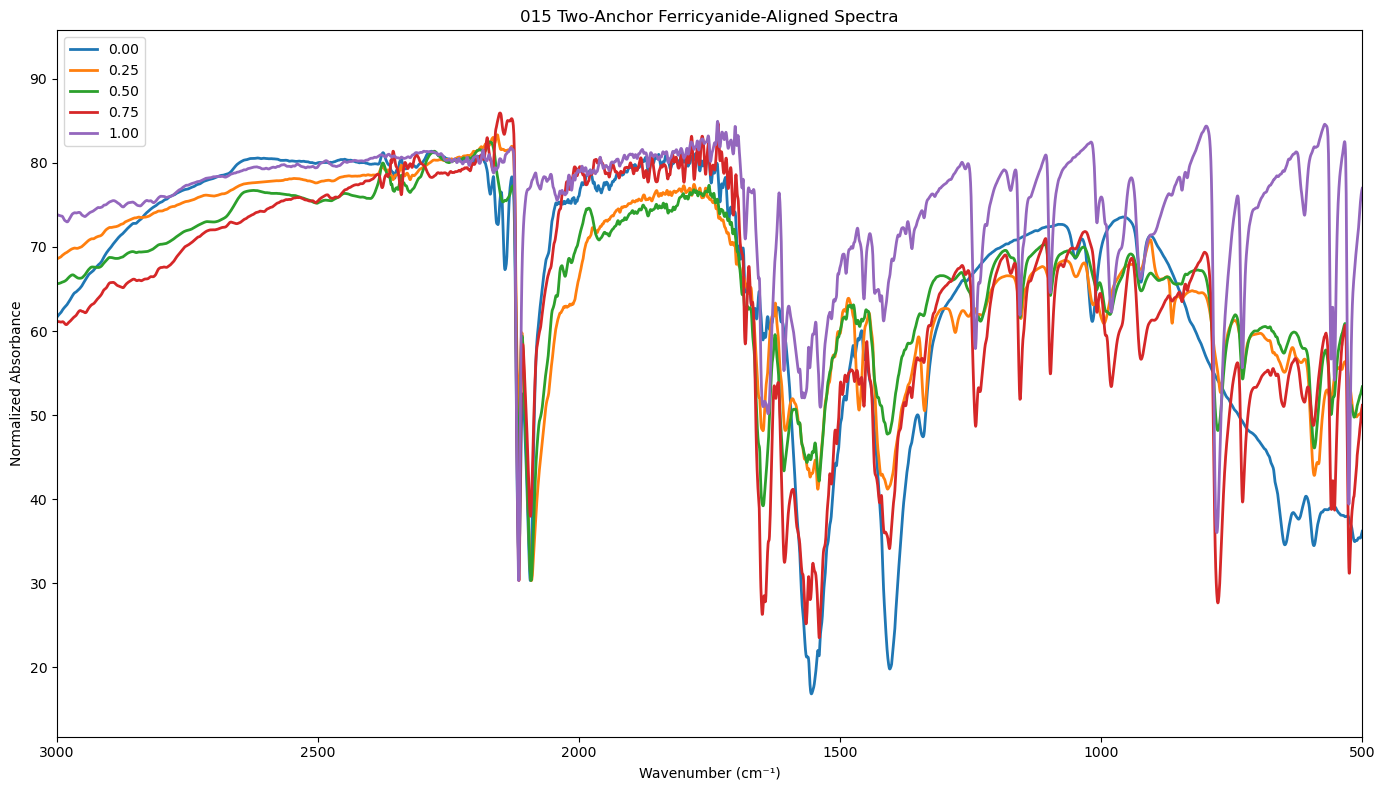


DONE.


In [4]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_FOLDER = r"/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2026_015"
OUTPUT_FOLDER = os.path.join(DATA_FOLDER, "response_factor_affine_output")
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

REFERENCE_RATIO = 0.25

# Ferricyanide regions
PEAK_MIN, PEAK_MAX = 2000, 2200   # peak (dip)
BASE_MIN, BASE_MAX = 2200, 2400   # baseline (stem)

# LOAD SPECTRUM

def read_spectrum(filepath):
    df = pd.read_csv(filepath)

    wn = pd.to_numeric(df.iloc[:, 0], errors="coerce")
    absorbance = pd.to_numeric(df.iloc[:, 1], errors="coerce")

    mask = ~(wn.isna() | absorbance.isna())

    return wn[mask].to_numpy(), absorbance[mask].to_numpy()

# PARSE RATIO

def get_ratio(filename):
    name = filename.lower()

    if "_alpha_" in name:
        return 1.0
    if "_agoac_" in name:
        return 0.0

    match = re.search(r'0\.25|0\.5|0\.75', name)
    return float(match.group()) if match else None

# GROUP FILES

groups = {}
all_min, all_max = [], []

for file in os.listdir(DATA_FOLDER):

    if not file.endswith(".CSV"):
        continue

    ratio = get_ratio(file)
    if ratio is None:
        continue

    path = os.path.join(DATA_FOLDER, file)

    wn, abs_ = read_spectrum(path)

    all_min.append(np.min(wn))
    all_max.append(np.max(wn))

    groups.setdefault(ratio, []).append((wn, abs_))

print("\nLoaded groups:")
for r in sorted(groups):
    print(f"{r}: {len(groups[r])} spectra")

# COMMON GRID

common_wn = np.linspace(max(all_min), min(all_max), 7000)

# INTERPOLATE + AVERAGE

avg_spectra = {}

for ratio, spectra in groups.items():

    interp_list = []

    for wn, abs_ in spectra:

        order = np.argsort(wn)
        wn = wn[order]
        abs_ = abs_[order]

        interp = np.interp(common_wn, wn, abs_)
        interp_list.append(interp)

    avg_spectra[ratio] = np.mean(interp_list, axis=0)

# FERRICYANIDE FEATURE EXTRACTION

def ferri_features(wn, spectrum):

    peak_mask = (wn >= PEAK_MIN) & (wn <= PEAK_MAX)
    base_mask = (wn >= BASE_MIN) & (wn <= BASE_MAX)

    peak_region = spectrum[peak_mask]
    base_region = spectrum[base_mask]

    peak_val = np.min(peak_region)   # dip
    base_val = np.max(base_region)   # stem

    return peak_val, base_val

# REFERENCE FEATURES (0.25)

ref_spectrum = avg_spectra[REFERENCE_RATIO]
ref_peak, ref_base = ferri_features(common_wn, ref_spectrum)

print("\nReference (0.25):")
print("Peak:", ref_peak)
print("Base:", ref_base)

# TWO-POINT AFFINE NORMALIZATION

normalized = {}

print("\nAffine normalization parameters:")

for ratio, spectrum in avg_spectra.items():

    peak, base = ferri_features(common_wn, spectrum)

    # Solve:
    # a*peak + b = ref_peak
    # a*base + b = ref_base

    a = (ref_base - ref_peak) / (base - peak)
    b = ref_peak - a * peak

    normalized[ratio] = a * spectrum + b

    print(f"Ratio {ratio:.2f} | a={a:.6f} | b={b:.6f}")

# OVERLAY PLOT (CHECK ALIGNMENT)

plt.figure(figsize=(14, 8))

for ratio in sorted(normalized):

    plt.plot(
        common_wn,
        normalized[ratio],
        linewidth=2,
        label=f"{ratio:.2f}"
    )

plt.gca().invert_xaxis()
plt.xlim(500, 3000)

plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Normalized Absorbance")
plt.title("015 Two-Anchor Ferricyanide-Aligned Spectra")

plt.legend()
plt.tight_layout()

plt.savefig(
    os.path.join(OUTPUT_FOLDER, "affine_normalized_overlay.png"),
    dpi=300
)
plt.gca().invert_xaxis()
plt.show()

print("\nDONE.")